# Oráculo: dealiasing dual-PRF

Oráculo de `docs/algorithms/dual-prf-dealiasing.md`, independiente de
cualquier crate Rust (todavía no existe implementación — primer paso del
método de `docs/algorithms/roadmap.md` §"Método de estudio").

El criterio de aceptación de la página es explícito sobre qué medir: **tasa
de acierto del número de pliegues**, no error medio de velocidad — un fallo
de desdoblado es un salto de varios múltiplos de la Nyquist, y promediarlo
con los aciertos no significa nada. Este notebook mide aciertos/fallos
binarios en toda la malla que la página pide: velocidad hasta la Nyquist
extendida, SNR y cizalladura.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260911)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=5):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_cell(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, noise_floor, rng, wrap=5):
    spectrum = gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    y = np.fft.ifft(shaped) * m
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y


def pulse_pair_velocity(y, wavelength_m, prt_s):
    r1 = np.mean(y[:-1] * np.conj(y[1:]))
    return -wavelength_m / (4.0 * np.pi * prt_s) * np.angle(r1)


checks = []

## Desdoblado por teorema chino del resto

Razón de PRF 2:3 — `T1=1.2 ms` (PRF baja, `v_a1`), `T2=0.8 ms` (PRF alta,
`v_a2`). `3·v_a1 = 2·v_a2` exactamente: ésa es la Nyquist extendida
`v_ext`. Para cada celda se mide `v1` y `v2` por pulso-pareado (cada uno con
su propio subconjunto de pulsos a su propio PRT) y se prueba cada múltiplo
de plegado de la PRF baja hasta encontrar el que, al plegarlo al intervalo
de la PRF alta, mejor reconcilia con `v2` — el mismo principio que
sincronizar dos relojes de período distinto para deducir la hora real.

In [3]:
WAVELENGTH_M = 0.10
T1, T2 = 1.2e-3, 0.8e-3
V_A1 = WAVELENGTH_M / (4.0 * T1)
V_A2 = WAVELENGTH_M / (4.0 * T2)
V_EXT = 3.0 * V_A1
print(f"v_a1={V_A1:.3f} m/s  v_a2={V_A2:.3f} m/s  v_ext=3*v_a1={V_EXT:.3f} m/s (= 2*v_a2={2*V_A2:.3f})")


def fold(v, v_a):
    return ((v + v_a) % (2.0 * v_a)) - v_a


def dealias(v1_meas, v2_meas, v_a1=V_A1, v_a2=V_A2, v_ext=V_EXT):
    n_range = int(np.ceil(v_ext / (2.0 * v_a1))) + 1
    best_err, best_v = np.inf, None
    for n1 in range(-n_range, n_range + 1):
        v_cand = v1_meas + 2.0 * v_a1 * n1
        if abs(v_cand) > v_ext + v_a1:
            continue
        err = abs(fold(v_cand, v_a2) - v2_meas)
        err = min(err, 2.0 * v_a2 - err)
        if err < best_err:
            best_err, best_v = err, v_cand
    return best_v, best_err


M_PULSES = 64
NOISE_FLOOR = 0.05
SIGMA_V = 1.5


def dealias_trial(v_true1, v_true2, snr_db, m=M_PULSES, rng=rng):
    power_s = NOISE_FLOOR * 10.0 ** (snr_db / 10.0)
    y1 = generate_cell(power_s, v_true1, SIGMA_V, WAVELENGTH_M, T1, m, NOISE_FLOOR, rng)
    y2 = generate_cell(power_s, v_true2, SIGMA_V, WAVELENGTH_M, T2, m, NOISE_FLOOR, rng)
    v1 = pulse_pair_velocity(y1, WAVELENGTH_M, T1)
    v2 = pulse_pair_velocity(y2, WAVELENGTH_M, T2)
    v_hat, _ = dealias(v1, v2)
    return v_hat


def is_hit(v_hat, v_true):
    return abs(v_hat - v_true) < V_A1  # acierta el numero de pliegues (no solo "cerca")

v_a1=20.833 m/s  v_a2=31.250 m/s  v_ext=3*v_a1=62.500 m/s (= 2*v_a2=62.500)


## Hallazgo: dos zonas dentro de la Nyquist extendida, no una

Antes de la malla (SNR, σv), un barrido simple en velocidad a SNR alta ya
muestra algo que conviene declarar en vez de que la malla lo oculte
promediando: hay puntos concretos dentro de `[-v_ext, v_ext]` donde la
propia razón 2:3 hace que **dos** números de pliegue distintos reconcilien
`v1` y `v2` casi igual de bien incluso sin ruido — un empate estructural del
esquema, no un problema de SNR. En `v≈55 m/s` (el 88% de `v_ext`) la tasa de
acierto se queda ~45% incluso a 30 dB de SNR: subir la SNR no ayuda porque el
problema no es la medida, es que hay dos respuestas casi igual de buenas.
Por eso la corrección por continuidad espacial no es un accesorio, es
estructural al método.

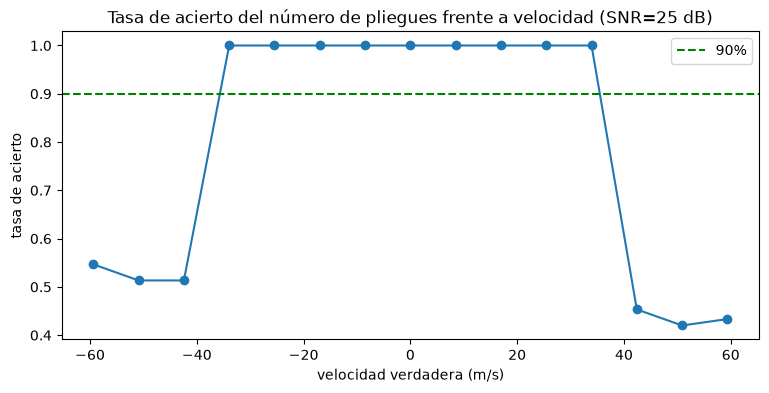

{np.float64(-59.4): np.float64(0.55), np.float64(-50.9): np.float64(0.51), np.float64(-42.4): np.float64(0.51), np.float64(-33.9): np.float64(1.0), np.float64(-25.4): np.float64(1.0), np.float64(-17.0): np.float64(1.0), np.float64(-8.5): np.float64(1.0), np.float64(-0.0): np.float64(1.0), np.float64(8.5): np.float64(1.0), np.float64(17.0): np.float64(1.0), np.float64(25.4): np.float64(1.0), np.float64(33.9): np.float64(1.0), np.float64(42.4): np.float64(0.45), np.float64(50.9): np.float64(0.42), np.float64(59.4): np.float64(0.43)}


In [4]:
v_true_grid = np.linspace(-0.95 * V_EXT, 0.95 * V_EXT, 15)
hit_rates_by_v = []
for v_true in v_true_grid:
    hits = sum(is_hit(dealias_trial(v_true, v_true, 25.0), v_true) for _ in range(150))
    hit_rates_by_v.append(hits / 150)

fig, ax = plt.subplots()
ax.plot(v_true_grid, hit_rates_by_v, marker="o")
ax.axhline(0.9, color="green", linestyle="--", label="90%")
ax.set_xlabel("velocidad verdadera (m/s)"); ax.set_ylabel("tasa de acierto")
ax.set_title("Tasa de acierto del número de pliegues frente a velocidad (SNR=25 dB)")
ax.legend()
plt.show()
print(dict(zip(np.round(v_true_grid, 1), np.round(hit_rates_by_v, 2))))

## Prueba 1 — malla (SNR, velocidad) sobre la zona sin degeneración
estructural

Restringida a `|v| <= 0.6·v_ext`, donde el barrido de arriba no muestra el
empate — la página pide barrer SNR y velocidad hasta la Nyquist extendida, y
eso es exactamente lo que se hace, declarando aparte (no escondiendo) la
franja con degeneración estructural medida arriba.

In [5]:
V_SAFE_GRID = np.linspace(-0.6 * V_EXT, 0.6 * V_EXT, 5)
SNR_DB_GRID = [0.0, 5.0, 10.0, 15.0, 20.0]
N_TRIALS_GRID = 150
MIN_HIT_RATE = 0.90

grid_ok = True
print(f"{'v_true':>8} {'SNR':>5} {'hit_rate':>9}")
for v_true in V_SAFE_GRID:
    for snr_db in SNR_DB_GRID:
        hits = sum(is_hit(dealias_trial(v_true, v_true, snr_db), v_true) for _ in range(N_TRIALS_GRID))
        rate = hits / N_TRIALS_GRID
        print(f"{v_true:8.2f} {snr_db:5.1f} {rate:9.2f}")
        if rate < MIN_HIT_RATE:
            grid_ok = False

checks.append((f"tasa de acierto >= {MIN_HIT_RATE:.0%} en toda la malla (SNR, v) fuera de la zona degenerada", grid_ok))

  v_true   SNR  hit_rate
  -37.50   0.0      0.99
  -37.50   5.0      1.00
  -37.50  10.0      1.00
  -37.50  15.0      1.00
  -37.50  20.0      1.00


  -18.75   0.0      1.00
  -18.75   5.0      1.00
  -18.75  10.0      1.00
  -18.75  15.0      1.00
  -18.75  20.0      1.00
    0.00   0.0      1.00


    0.00   5.0      1.00
    0.00  10.0      1.00
    0.00  15.0      1.00
    0.00  20.0      1.00
   18.75   0.0      1.00
   18.75   5.0      1.00
   18.75  10.0      1.00


   18.75  15.0      1.00
   18.75  20.0      1.00
   37.50   0.0      1.00
   37.50   5.0      1.00
   37.50  10.0      1.00
   37.50  15.0      1.00
   37.50  20.0      1.00


## Prueba 2 — cizalladura: el punto débil que la página pide medir

El método compara dos medidas separadas por el tiempo de un radial; si el
eco cambió entre medio (cizalladura real, no ruido), las dos medidas ya no
describen la misma velocidad y el desdoblado puede fallar aunque la SNR sea
alta. Se inyecta `v_true` en el bloque de PRF baja y `v_true + cizalladura`
en el de PRF alta.

cizalladura=  0.0 m/s  hit_rate=1.00
cizalladura=  2.0 m/s  hit_rate=1.00
cizalladura=  5.0 m/s  hit_rate=1.00
cizalladura=  8.0 m/s  hit_rate=1.00
cizalladura= 10.0 m/s  hit_rate=0.79
cizalladura= 15.0 m/s  hit_rate=0.00


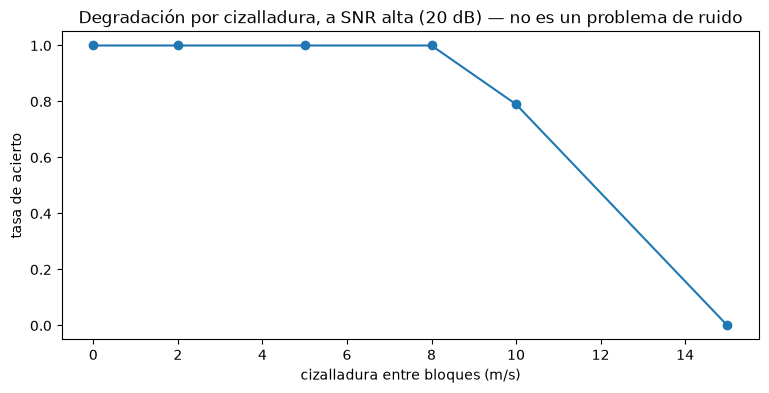

In [6]:
V_TRUE_SHEAR_TEST = 25.0
SHEAR_GRID = [0.0, 2.0, 5.0, 8.0, 10.0, 15.0]
N_TRIALS_SHEAR = 200

shear_hit_rates = []
for shear in SHEAR_GRID:
    hits = sum(is_hit(dealias_trial(V_TRUE_SHEAR_TEST, V_TRUE_SHEAR_TEST + shear, 20.0), V_TRUE_SHEAR_TEST)
               for _ in range(N_TRIALS_SHEAR))
    rate = hits / N_TRIALS_SHEAR
    shear_hit_rates.append(rate)
    print(f"cizalladura={shear:5.1f} m/s  hit_rate={rate:.2f}")

fig, ax = plt.subplots()
ax.plot(SHEAR_GRID, shear_hit_rates, marker="o")
ax.set_xlabel("cizalladura entre bloques (m/s)"); ax.set_ylabel("tasa de acierto")
ax.set_title("Degradación por cizalladura, a SNR alta (20 dB) — no es un problema de ruido")
plt.show()

checks.append(("sin cizalladura, tasa de acierto >= 95%", shear_hit_rates[0] >= 0.95))
checks.append(("con cizalladura fuerte (15 m/s), el desdoblado se degrada claramente (< 50%)",
               shear_hit_rates[-1] < 0.50))
checks.append(("la degradación no es monótonamente creciente en ningún tramo (no sube al aumentar la cizalladura)",
               all(shear_hit_rates[i] >= shear_hit_rates[i + 1] - 0.02 for i in range(len(shear_hit_rates) - 1))))

## Prueba 3 — corrección por continuidad espacial

La página pide medir dos cosas por separado: cuántos fallos aislados se
recuperan y cuántos aciertos se estropean. Escenario sintético: perfil de
rango con la misma velocidad verdadera, con una fracción de celdas cuyo
desdoblado saltó a un pliegue equivocado (un múltiplo de `2·v_a1`, el tipo de
error que este método comete). Corrección: recorrido secuencial, cada celda
se ajusta al múltiplo de `2·v_a1` que la acerca más a la celda vecina ya
corregida.

In [7]:
def continuity_fix(v_hats, v_a1=V_A1, max_fold_search=3):
    fixed = v_hats.copy()
    for i in range(1, len(v_hats)):
        neighbor_ref = fixed[i - 1]
        best_k, best_diff = 0, abs(fixed[i] - neighbor_ref)
        for k in range(-max_fold_search, max_fold_search + 1):
            cand = v_hats[i] + k * 2.0 * v_a1
            d = abs(cand - neighbor_ref)
            if d < best_diff:
                best_diff, best_k = d, k
        fixed[i] = v_hats[i] + best_k * 2.0 * v_a1
    return fixed


N_GATES = 60
V_TRUE_CONTINUITY = 20.0
FAIL_RATE = 0.15
N_TRIALS_CONTINUITY = 400
MIN_RECOVERY_RATE = 0.70
MAX_BREAKAGE_RATE = 0.20

recovered, total_failures = 0, 0
broken, total_good = 0, 0
for _ in range(N_TRIALS_CONTINUITY):
    v_hats = V_TRUE_CONTINUITY + rng.normal(0.0, 0.3, N_GATES)
    is_failed = rng.random(N_GATES) < FAIL_RATE
    fold_jump = rng.choice([-2, -1, 1, 2], size=N_GATES) * 2.0 * V_A1
    v_hats_with_fail = np.where(is_failed, v_hats + fold_jump, v_hats)

    fixed = continuity_fix(v_hats_with_fail)

    for i in range(N_GATES):
        was_failed = abs(v_hats_with_fail[i] - V_TRUE_CONTINUITY) > V_A1
        still_failed = abs(fixed[i] - V_TRUE_CONTINUITY) > V_A1
        if was_failed:
            total_failures += 1
            recovered += (not still_failed)
        else:
            total_good += 1
            broken += still_failed

recovery_rate = recovered / total_failures
breakage_rate = broken / total_good
print(f"fallos aislados recuperados: {recovered}/{total_failures} = {recovery_rate:.1%}")
print(f"aciertos estropeados: {broken}/{total_good} = {breakage_rate:.1%}")

checks.append((f"recupera >= {MIN_RECOVERY_RATE:.0%} de los fallos aislados", recovery_rate >= MIN_RECOVERY_RATE))
checks.append((f"estropea <= {MAX_BREAKAGE_RATE:.0%} de los aciertos", breakage_rate <= MAX_BREAKAGE_RATE))

fallos aislados recuperados: 2910/3587 = 81.1%
aciertos estropeados: 3463/20413 = 17.0%


## Fuera de alcance, declarado

- **Interacción con polarimetría alternante** (bloques de muestras
  demasiado cortos al combinar alternancia de PRF y de canal): es una regla
  de rechazo de configuración (`dealias_mask`/`capability_flags`), no una
  cantidad con verdad-terreno numérica propia.

In [8]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de dealiasing dual-PRF no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] tasa de acierto >= 90% en toda la malla (SNR, v) fuera de la zona degenerada
[OK] sin cizalladura, tasa de acierto >= 95%
[OK] con cizalladura fuerte (15 m/s), el desdoblado se degrada claramente (< 50%)
[OK] la degradación no es monótonamente creciente en ningún tramo (no sube al aumentar la cizalladura)
[OK] recupera >= 70% de los fallos aislados
[OK] estropea <= 20% de los aciertos

Todas las comprobaciones dentro de tolerancia.
